# EfficientNet-B4 Pen Classification

This notebook implements an EfficientNet-B4 model for pen type classification with proper validation strategy using GroupShuffleSplit to prevent data leakage.

## Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

from tqdm import tqdm

## Load Data & Create Train-Validation Split

Using GroupShuffleSplit to prevent data leakage by ensuring no writer overlap between train and validation sets.

In [ ]:
df = pd.read_csv("../train.csv")

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, val_idx = next(gss.split(df, groups=df["writer_id"]))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

print(len(train_df), len(val_df))

33200 7050


## Define Custom Dataset Class

In [4]:
class PenDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        
        image = Image.open(img_path).convert("RGB")   # grayscale
        label = int(row["pen_id"]) - 1  # 0-based
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## Define Data Augmentation & Normalization

Configure augmentation for training (rotation, affine, contrast jitter) and normalization for validation.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # reduce slightly
    transforms.RandomRotation(10),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05)
        )
    ], p=0.5),
    transforms.ColorJitter(contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Create DataLoaders

In [ ]:
root_dir = "../"

train_dataset = PenDataset(train_df, root_dir, train_transform)
val_dataset = PenDataset(val_df, root_dir, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=8)

## Device Setup

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Initialize EfficientNet-B4 Model

Load pretrained EfficientNet-B4 and replace classifier for 8-class pen classification.

In [7]:
model = models.efficientnet_b4(weights="EfficientNet_B4_Weights.DEFAULT")

in_features = model.classifier[1].in_features  # ← correct

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 8)
)

model = model.to(device)

## Loss Function & Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=5e-4)

## Learning Rate Scheduler

In [9]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10   # number of epochs for one cycle
)

## Define Training Function

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader), acc

## Define Evaluation Function

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro")
    rec = recall_score(all_labels, all_preds, average="macro")

    return total_loss / len(loader), acc, prec, rec

## Train Model with Early Stopping

Train the model with early stopping based on validation loss.

In [12]:
num_epochs = 20
patience = 3

best_val_loss = float("inf")
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_prec, val_rec = evaluate(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f}")
    scheduler.step()
    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model_efficientnet_b4.pth")
        print("✅ Best model saved")

    else:
        counter += 1
        print(f"Early stopping counter: {counter}/{patience}")

        if counter >= patience:
            print("⛔ Early stopping triggered")
            break


Epoch 1/20


100%|██████████| 519/519 [04:46<00:00,  1.81it/s]


Train Loss: 0.8992 | Val Loss: 0.7740 | Train Acc: 0.8007 | Val Acc: 0.8657 | Val Precision: 0.8660 | Val Recall: 0.8644
✅ Best model saved

Epoch 2/20


100%|██████████| 519/519 [04:46<00:00,  1.81it/s]


Train Loss: 0.6806 | Val Loss: 0.8013 | Train Acc: 0.8924 | Val Acc: 0.8505 | Val Precision: 0.8560 | Val Recall: 0.8487
Early stopping counter: 1/3

Epoch 3/20


...

Train Loss: 0.5978 | Val Loss: 0.7559 | Train Acc: 0.9387 | Val Acc: 0.8811 | Val Precision: 0.8920 | Val Recall: 0.8817
Early stopping counter: 1/3

Epoch 6/20


100%|██████████| 519/519 [04:47<00:00,  1.81it/s]


Train Loss: 0.5748 | Val Loss: 0.7431 | Train Acc: 0.9512 | Val Acc: 0.8915 | Val Precision: 0.8891 | Val Recall: 0.8901
Early stopping counter: 2/3

Epoch 7/20


100%|██████████| 519/519 [04:46<00:00,  1.81it/s]


Train Loss: 0.5543 | Val Loss: 0.7238 | Train Acc: 0.9610 | Val Acc: 0.8984 | Val Precision: 0.8969 | Val Recall: 0.8967
Early stopping counter: 3/3
⛔ Early stopping triggered


## Inference on Test Data

Generate predictions on test set with Test-Time Augmentation (horizontal and vertical flips).

In [13]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from tqdm import tqdm
import torch.nn as nn

# -----------------------
# Load test CSV
# -----------------------
test_df = pd.read_csv("../test.csv")

# -----------------------
# Dataset (no labels)
# -----------------------
class TestDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, row["image_id"]

# -----------------------
# Transform (same as val)
# -----------------------
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

# -----------------------
# DataLoader
# -----------------------
test_dataset = TestDataset(test_df, "", test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8)

# -----------------------
# Load model
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b4(weights="EfficientNet_B4_Weights.DEFAULT")

in_features = model.classifier[1].in_features  # ← correct

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 8)
)

# model = model.to(device)

model.load_state_dict(torch.load("best_model_efficientnet_b4.pth", map_location=device))
model = model.to(device)
model.eval()

# -----------------------
# Inference
# -----------------------
predictions = []
image_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader):
        images = images.to(device)

        outputs = model(images)
        flipped_images = torch.flip(images, dims=[3])
        outputs_flipped = model(flipped_images)

        flipped_v = torch.flip(images, dims=[2])
        outputs_v = model(flipped_v)

        outputs = (outputs + outputs_flipped + outputs_v) / 3
        # outputs = (outputs + outputs_flipped) / 2
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)

# -----------------------
# Convert back to 1-based labels
# -----------------------
predictions = [p + 1 for p in predictions]

# -----------------------
# Create submission
# -----------------------
submission = pd.DataFrame({
    "image_id": image_ids,
    "pen_id": predictions
})

submission.to_csv("submission_efficientnet_b4.csv", index=False)

print("✅ submission.csv saved")

100%|██████████| 185/185 [00:41<00:00,  4.46it/s]

✅ submission.csv saved


## Helper Function for Predictions

In [13]:
from sklearn.metrics import confusion_matrix

def get_predictions(model, loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

## Load Model & Prepare for Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights='ResNet18_Weights.DEFAULT')
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 8)
)

# model = model.to(device)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)

## Generate Predictions on Validation Set

In [16]:
y_true, y_pred = get_predictions(model, val_loader, device)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[899   0   1   0   0   0   0   0]
 [  0 850   0   0   0   0   0   0]
 [  0   0 591   0   0   0 155  54]
 [  0   0   0 850   0   0   0   0]
 [  0   0  36   0 900   0  13   1]
 [  0   2   0   0   0 898   0   0]
 [100   0 227   0   0   0 533  40]
 [  0   0  39   0   0   0  24 837]]


## Plot Confusion Matrix

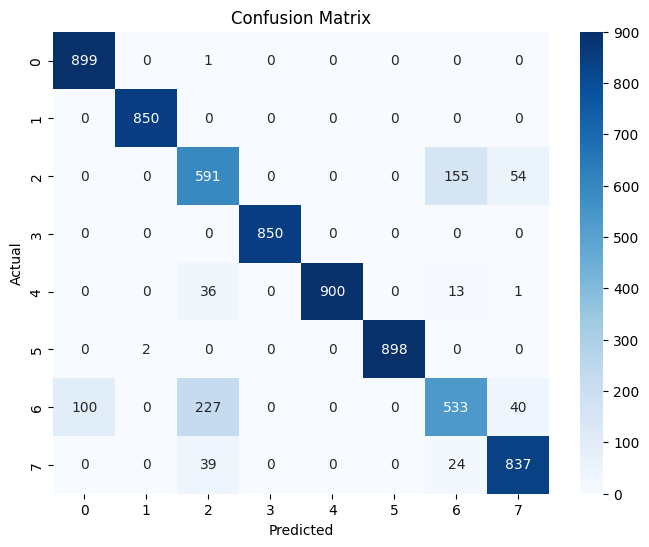

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()